# scRNA-seq

In [609]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sn
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import itertools

scvi.settings.seed = 30

Seed set to 30


### Annotate Single Cells with Cell Type Label

In [2]:
######################################################## load reference
ref_data = sc.read_h5ad('TS_Mammary.h5ad')
print(ref_data)

######################################################## load data
file = 'scrnaseq_processed_data_10232025.h5ad' ### <--- data
#file = 'scrnaseq_processed_data_EDIT.h5ad' ### <--- data
#file = 'sc_rna_seq_combined.h5ad' ### <--- data

dat1 = sc.read_h5ad(file)
#dat1.obs.to_csv("dat1.csv")
print(dat1)
print("After reload:", dat1.obs['Sample'].unique())

######################################################## concatenate data
dat1 = dat1.concatenate(ref_data)

AnnData object with n_obs × n_vars = 11375 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 10097 × 29733
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_count

In [3]:
dat1

AnnData object with n_obs × n_vars = 21472 × 20574
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'batch'
    var: 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'

In [4]:
dat1.obs

,Sample,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,batch
CID3941_ACAGCCGAGCTCTCGG-0,ER_CID3941,False,2456.0,6685.0,578.0,8.646223,1031.0,15.422588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3941_ACGCAGCCAGCTGTAT-0,ER_CID3941,False,2305.0,7904.0,740.0,9.362349,1447.0,18.307186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3941_CATGACAGTAGAGCTG-0,ER_CID3941,False,1944.0,4935.0,251.0,5.086120,980.0,19.858156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3941_CGAACATTCCCAACGG-0,ER_CID3941,False,1492.0,3354.0,277.0,8.258796,492.0,14.669052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3941_CTAGAGTGTAAAGGAG-0,ER_CID3941,False,1353.0,3263.0,375.0,11.492492,643.0,19.705791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P16_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,416893.0,456.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P19_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,115929.0,509.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P20_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,1673903.0,1859.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P3_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,459043.0,1063.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1


In [5]:
dat1.X

<21472x20574 sparse matrix of type '<class 'numpy.float32'>'
	with 46603983 stored elements in Compressed Sparse Row format>

In [6]:
dat1_copy = dat1.copy()

In [7]:
#dat1_copy.obs.to_csv("dat1_copy_obs.csv")

In [8]:
######################################################## normalize data
dat1.layers["counts"] = dat1.X.copy()
sc.pp.normalize_total(dat1, target_sum = 10000)
sc.pp.log1p(dat1)
dat1.raw = dat1

print(dat1)
######################################################## filter
sc.pp.highly_variable_genes(dat1, flavor = 'seurat_v3', n_top_genes=4000, layer = 'counts', subset = True)
print(dat1)

AnnData object with n_obs × n_vars = 21472 × 20574
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'batch'
    var: 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    uns: 'log1p'
    layers: 'counts'
AnnData object with n_obs × n_vars = 21472 × 4000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'batch'
    var: 'gene_symbol-1', 'feature_type-1', 'ensemblid-

In [9]:
######################################################## train model
scvi.model.SCVI.setup_anndata(dat1, layer = 'counts')
vae = scvi.model.SCVI(dat1) ### initialize the model
vae.train()

######################################################## predict label
dat1.obs['cell_ontology_class'] = dat1.obs['cell_ontology_class'].cat.add_categories('Unknown')
dat1.obs = dat1.obs.fillna(value = {'cell_ontology_class': 'Unknown'})

lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = dat1, unlabeled_category = 'Unknown', labels_key = 'cell_ontology_class')
lvae.train()

dat1.obs['predicted'] = lvae.predict(dat1)
dat1.obs['bc2'] = dat1.obs.index.map(lambda x: x[:-2])

######################################################## store labels in a dictionary
cell_mapper = dict(zip(dat1.obs.bc2, dat1.obs.predicted))

######################################################## map to data
dat1 = sc.read_h5ad(file)
dat1.var_names_make_unique()
dat1.obs['cell_type'] = dat1.obs.index.map(cell_mapper)
dat1.obs.groupby('Sample').count()
dat1.obs

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/373 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=373` reached.


INFO     Training for 10 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/10 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


,Sample,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,cell_type
CID3941_ACAGCCGAGCTCTCGG,ER_CID3941,False,2456,6685.0,578.0,8.646223,1031.0,15.422588,vein endothelial cell
CID3941_ACGCAGCCAGCTGTAT,ER_CID3941,False,2305,7904.0,740.0,9.362349,1447.0,18.307186,vein endothelial cell
CID3941_CATGACAGTAGAGCTG,ER_CID3941,False,1944,4935.0,251.0,5.086120,980.0,19.858156,vein endothelial cell
CID3941_CGAACATTCCCAACGG,ER_CID3941,False,1492,3354.0,277.0,8.258796,492.0,14.669052,vein endothelial cell
CID3941_CTAGAGTGTAAAGGAG,ER_CID3941,False,1353,3263.0,375.0,11.492492,643.0,19.705791,vein endothelial cell
...,...,...,...,...,...,...,...,...,...
CID4465_CGTGTCTAGTAAGTAC,TNBC_CID4465,False,1461,2954.0,92.0,3.114421,291.0,9.851049,luminal epithelial cell of mammary gland
CID4465_GAGTCCGGTGAGGGAG,TNBC_CID4465,False,1090,1888.0,61.0,3.230932,161.0,8.527543,luminal epithelial cell of mammary gland
CID4465_GTAACGTCAAGCCATT,TNBC_CID4465,False,268,389.0,30.0,7.712082,34.0,8.740359,luminal epithelial cell of mammary gland
CID4465_TGAGCCGCACGTCTCT,TNBC_CID4465,False,1324,2458.0,113.0,4.597234,181.0,7.363710,luminal epithelial cell of mammary gland


### Data Analysis

In [10]:
dat1

AnnData object with n_obs × n_vars = 10097 × 29733
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type'

In [11]:
############################### remove cells that do not meet the required minium number of genes
sc.pp.filter_cells(dat1, min_genes = 200) ### <-- 100

############################### remove genes that do not meet the required minium number of cells
sc.pp.filter_genes(dat1, min_cells = 10) ### <--- 10
dat1

AnnData object with n_obs × n_vars = 10097 × 20250
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells'

In [12]:
######################################################## normalize data
dat1.layers['counts'] = dat1.X.copy()
sc.pp.normalize_total(dat1, target_sum = 10000)
sc.pp.log1p(dat1)
dat1.raw = dat1

print(dat1)
######################################################## filter
sc.pp.highly_variable_genes(dat1, flavor='seurat_v3', n_top_genes=2000, layer='counts', subset=True)
print(dat1)

AnnData object with n_obs × n_vars = 10097 × 20250
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'
AnnData object with n_obs × n_vars = 10097 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


In [13]:
######################################################## train model
scvi.model.SCVI.setup_anndata(dat1, layer='counts',
                              categorical_covariate_keys=['Sample'],
                              #continuous_covariate_keys=['pct_counts_mt', 'total_counts', 'pct_counts_ribo'])
                              continuous_covariate_keys=['total_counts', 'pct_counts_ribo'])

model = scvi.model.SCVI(dat1)
model.train()

######################################################## prepare data for clustering
model.get_latent_representation().shape
dat1.obsm['X_scVI'] = model.get_latent_representation()
dat1.layers['scvi_normalized'] = model.get_normalized_expression(library_size=10000)

sc.pp.neighbors(dat1, use_rep = 'X_scVI')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.
2025-10-23 23:29:13.365770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761276553.389365   90152 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761276553.396540   90152 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [15]:
#dat10_copy = dat1.copy()

In [583]:
#dat1 = dat10_copy

In [584]:
import torch, random, numpy as np
seed = 30
scvi.settings.seed = seed
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Seed set to 30


In [585]:
#dat10_copy.obs
#dat10_copy.obs.to_csv("dat10_obs.csv")
#dat1.write_h5ad('scrnaseq_processed_data_10232025_FINAL.h5ad')

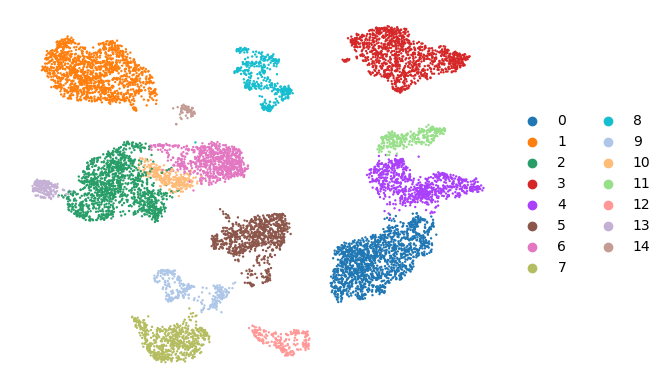

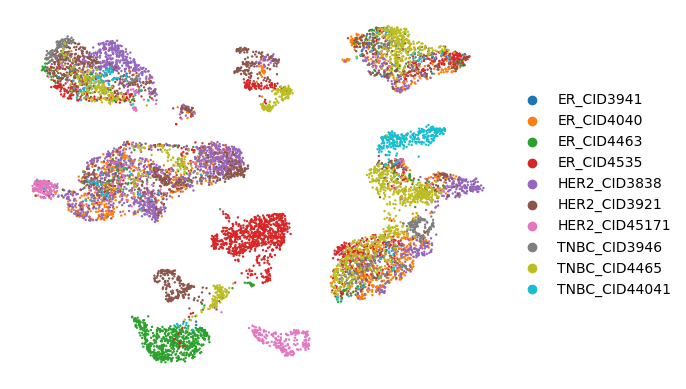

In [586]:
######################################################## plot umap, based on leiden clustering
sc.tl.umap(dat1)
sc.tl.leiden(dat1, resolution = 0.6)

sc.pl.umap(dat1, color = ['leiden'], frameon = False, title = "", save='UMAP_cell_type_scrnaseq.png') ### leiden clustering
sc.pl.umap(dat1, color = ['Sample'], frameon = False, title = "", save='UMAP_sample_scrnaseq.png') ### leiden clustering

In [587]:
######################################################## R Shiny
umap_df = pd.DataFrame({
    "cell_id": dat1.obs_names,
    "UMAP1": dat1.obsm['X_umap'][:, 0], 
    "UMAP2": dat1.obsm['X_umap'][:, 1],
    "leiden": dat1.obs['leiden'].values
})
umap_df.to_csv("data_umap_leiden_1.csv", index=False)

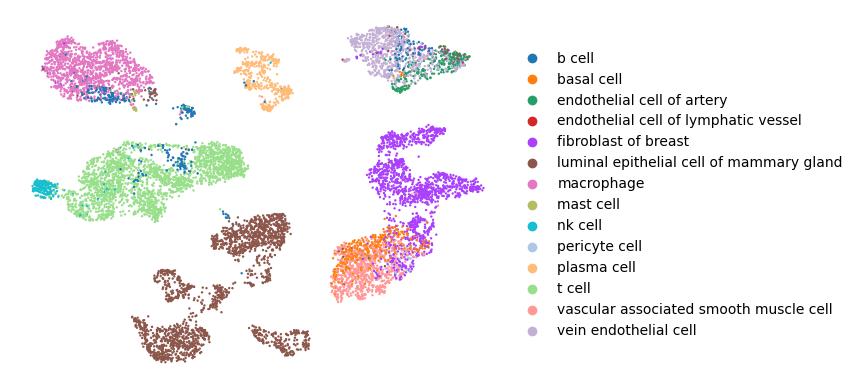

In [588]:
######################################################## plot umap, based on labelled cell type annotation from Tabula Sapiens Consortum
sc.pl.umap(dat1, color = 'cell_type', frameon = False, title = "")

In [589]:
dat1

AnnData object with n_obs × n_vars = 10097 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'Type'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Sample_colors', 'cell_type_colors', 'rank_genes_groups', 'Type_colors'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

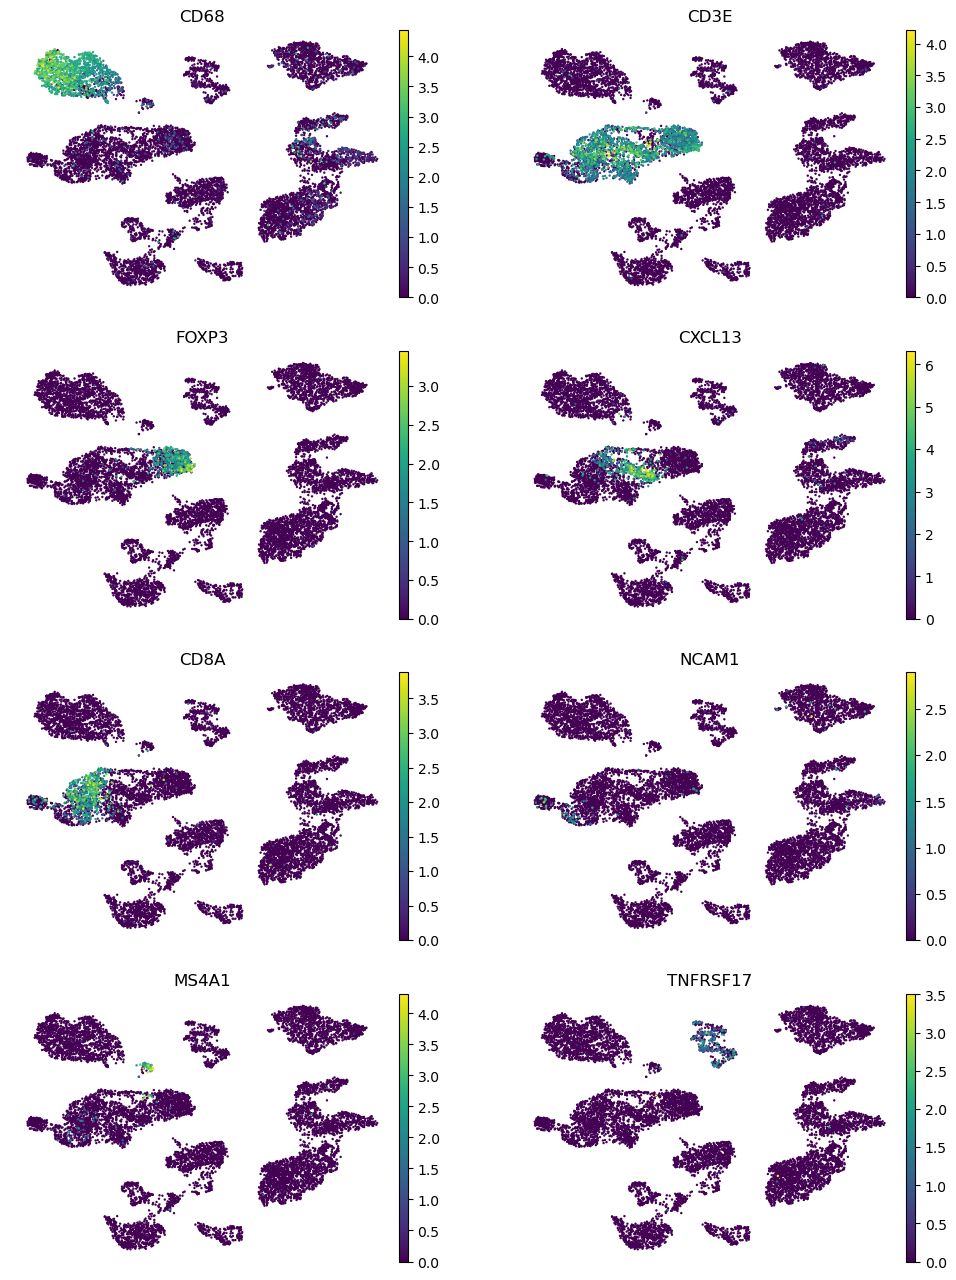

In [590]:
######################################################## plot biomarker genes
fig, axs = plt.subplots(4,2, figsize=(12,16))

sc.pl.umap(dat1, color = ['CD68'], frameon = False, ax=axs[0,0], show=False) ### macrophage
sc.pl.umap(dat1, color = ['CD3E'], frameon = False, ax=axs[0,1], show=False) ### T cells
sc.pl.umap(dat1, color = ['FOXP3'], frameon = False, ax=axs[1,0], show=False) ### CD4+ regulatory T cell (Tregs)
sc.pl.umap(dat1, color = ['CXCL13'] , frameon = False, ax=axs[1,1], show=False) ### CD4+ follicular helper cell (Tfh)
sc.pl.umap(dat1, color = ['CD8A'], frameon = False, ax=axs[2,0], show=False) ### CD8+ T cell
sc.pl.umap(dat1, color = ['NCAM1'], frameon = False, ax=axs[2,1], show=False) ### NK cell
sc.pl.umap(dat1, color = ['MS4A1'], frameon = False, ax=axs[3,0], show=False) ### B cell
sc.pl.umap(dat1, color = ['TNFRSF17'], frameon = False, ax=axs[3,1], show=False) ### plasma cell
#plt.delaxes(axs[3,1])
plt.savefig('biomarkers_scrnaseq_i.png')

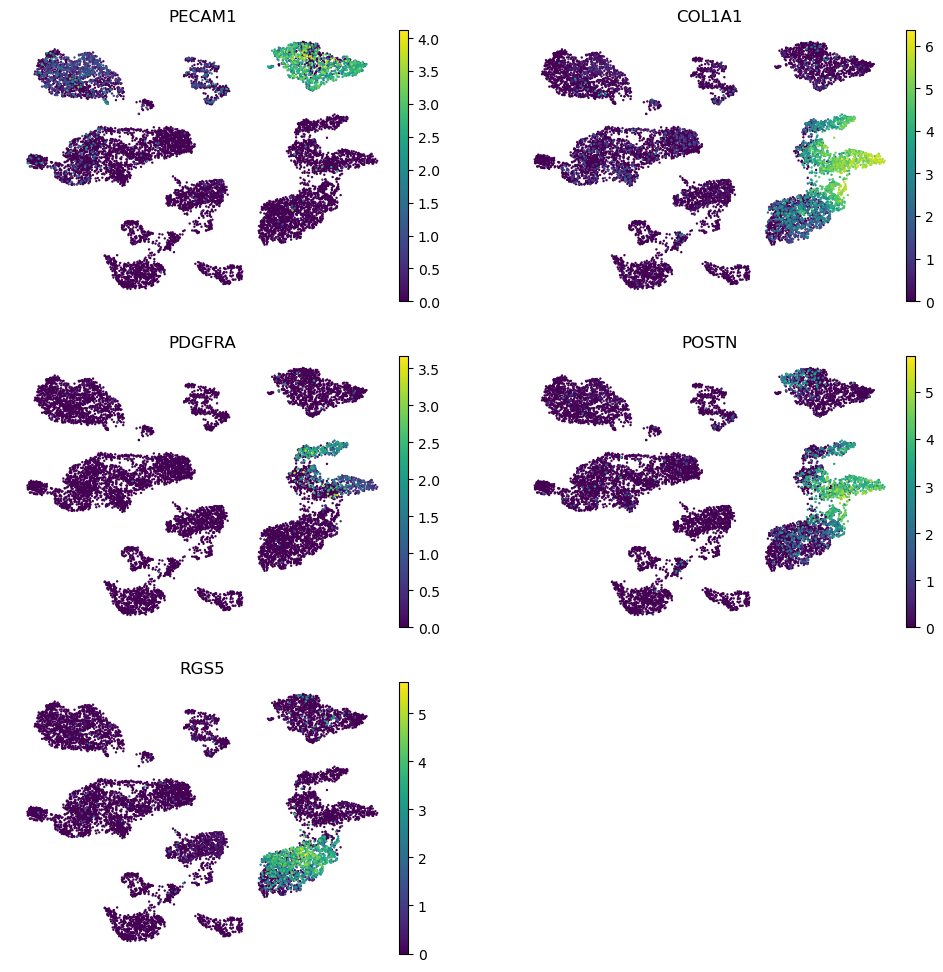

In [591]:
######################################################## plot biomarker genes
fig, axs = plt.subplots(3,2, figsize=(12,12))

sc.pl.umap(dat1, color = ['PECAM1'] , frameon = False, ax=axs[0,0], show=False) ### endothelial cell
sc.pl.umap(dat1, color = ['COL1A1'] , frameon = False, ax=axs[0,1], show=False) ### fibroblast cells COL1A1
sc.pl.umap(dat1, color = ['PDGFRA'], frameon = False, ax=axs[1,0], show=False) ### ECM fibroblast, PDGFRA, DCN
sc.pl.umap(dat1, color = ['POSTN'], frameon = False, ax=axs[1,1], show=False) ### myCAF, POSTN, TAGLN
sc.pl.umap(dat1, color = ['RGS5'], frameon = False, ax=axs[2,0], show=False) ### vascular CAF (vCAF)
plt.delaxes(axs[2,1])
plt.savefig('biomarkers_scrnaseq_ii.png')

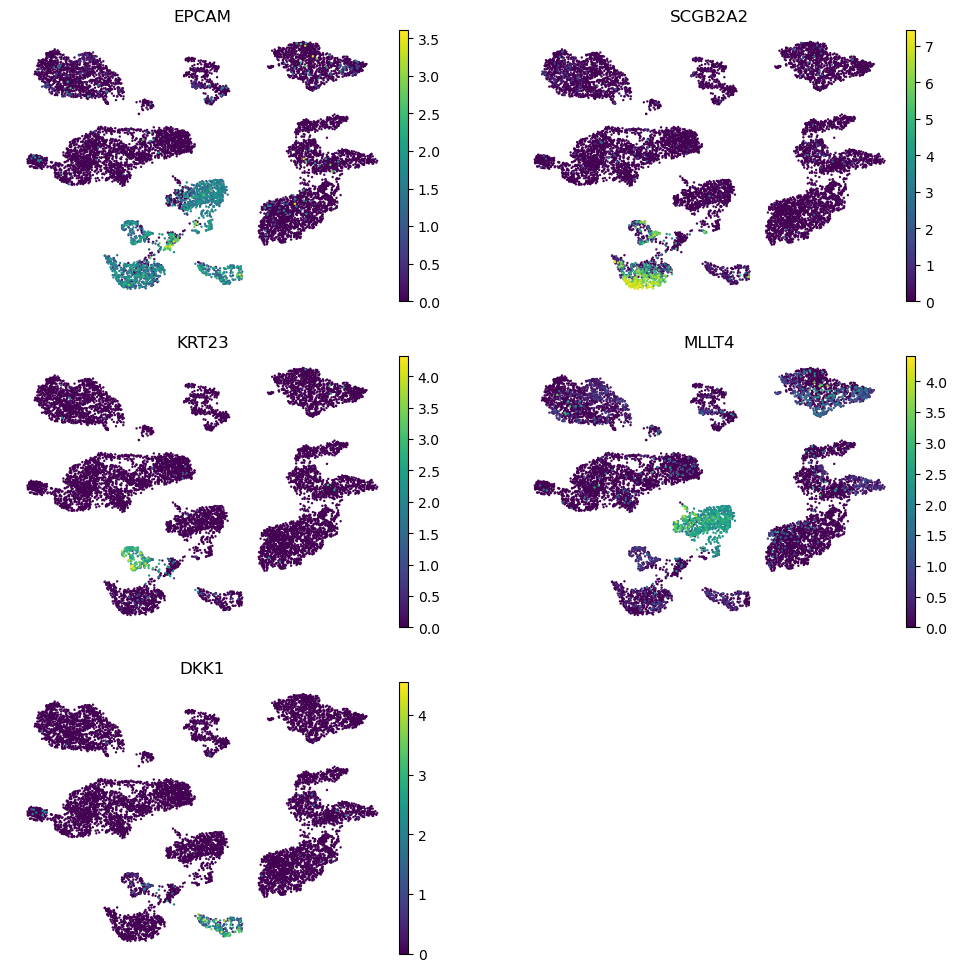

In [592]:
######################################################## plot biomarker genes
fig, axs = plt.subplots(3,2, figsize=(12,12))

sc.pl.umap(dat1, color = ['EPCAM'] , frameon = False, ax=axs[0,0], show=False) ### epithelial cells
sc.pl.umap(dat1, color = ['SCGB2A2'] , frameon = False, ax=axs[0,1], show=False) ### luminal L1 cell
sc.pl.umap(dat1, color = ['KRT23'], frameon = False, ax=axs[1,0], show=False) ### luminal L2 cell
sc.pl.umap(dat1, color = ['MLLT4'], frameon = False, ax=axs[1,1], show=False) ### junctional epithelial cell
sc.pl.umap(dat1, color = ['DKK1'], frameon = False, ax=axs[2,0], show=False) ### tumor epithelial cell
plt.delaxes(axs[2,1])
plt.savefig('biomarkers_scrnaseq_iii.png')

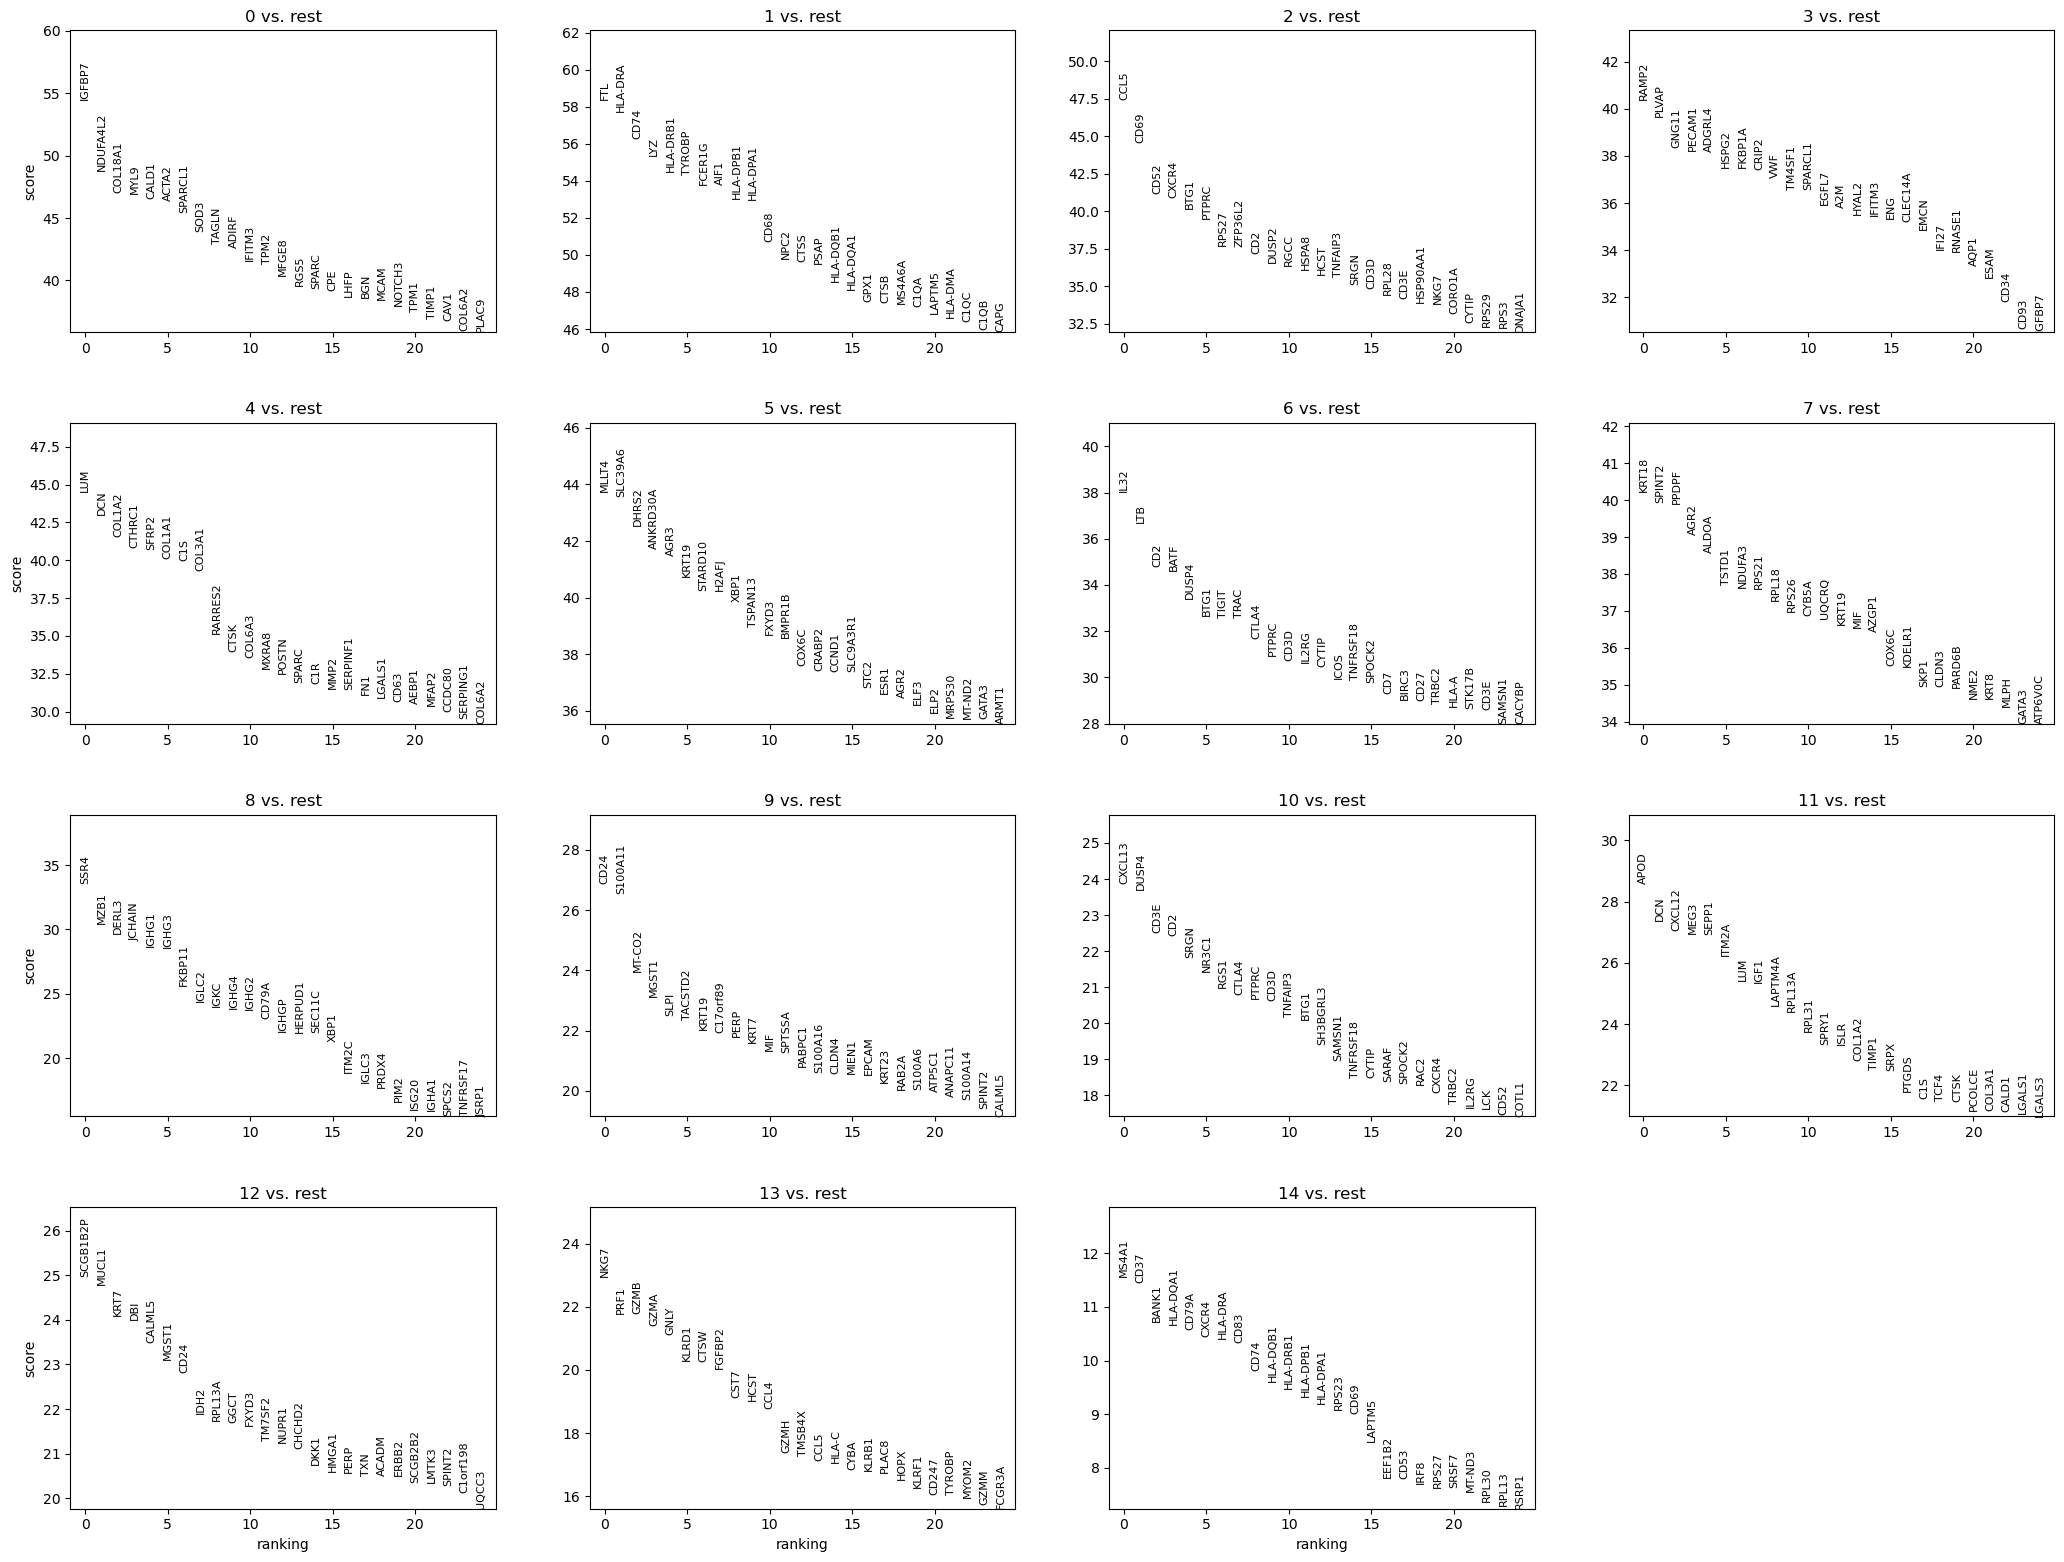

In [593]:
######################################################## compute differential expression by Wilcoxon test
sc.tl.rank_genes_groups(dat1, 'leiden', method="wilcoxon")
sc.pl.rank_genes_groups(dat1, n_genes=25, sharey=False)

######################################################## filter by adjusted p-values and log-fold-changes from Wilcoxon test
markers_all = sc.get.rank_genes_groups_df(dat1, None)
markers_all.to_csv('biomarker_raw.csv', index=False)
markers = markers_all[(markers_all.pvals_adj < 0.05) & (markers_all.logfoldchanges > 0.5)]
#markers.to_csv('biomarker_processed.csv', index=False)

In [594]:
#df = sc.get.rank_genes_groups_df(dat1, group='0')
#print(df)
#df.to_csv("cluster0_ranked_genes.csv", index=False)

In [595]:
######################################################## compute differential expression by scvi-DE
markers_scvi = model.differential_expression(adata=dat1, groupby='leiden')

######################################################## filter by FDR and log-fold-change mean from scvi-DE
markers_scvi = markers_scvi[(markers_scvi['is_de_fdr_0.05']) & (markers_scvi.lfc_mean > 0.5)]

DE...:   0%|          | 0/15 [00:00<?, ?it/s]

In [596]:
markers_scvi

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
NDUFA4L2,0.9910,0.0090,4.701489,0.011376,0.000412,0.006232,0.25,5.962486,6.072698,2.269969,...,10.272876,0.062078,0.798662,0.038247,116.661659,0.712555,True,0 vs Rest,0,Rest
COL18A1,0.9734,0.0266,3.599884,0.010689,0.000716,0.006232,0.25,5.304763,5.347520,2.452621,...,12.228730,0.564285,0.818060,0.151941,116.077408,5.293071,True,0 vs Rest,0,Rest
RGS5,0.9710,0.0290,3.511030,0.011401,0.000407,0.006232,0.25,6.549206,6.771725,2.779445,...,11.231413,0.075912,0.656187,0.035806,129.331772,1.048893,True,0 vs Rest,0,Rest
MYL9,0.9680,0.0320,3.409496,0.017450,0.001080,0.006232,0.25,5.081648,5.123622,2.443797,...,18.729115,1.839562,0.834114,0.225529,185.472214,7.982033,True,0 vs Rest,0,Rest
IGFBP7,0.9680,0.0320,3.409496,0.061907,0.007271,0.006232,0.25,5.031052,5.429778,2.647594,...,93.513657,9.866967,0.971237,0.375610,801.210876,80.829353,True,0 vs Rest,0,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PLAC8,0.9166,0.0834,2.397023,0.007093,0.000263,0.006455,0.25,5.944888,6.050056,2.393774,...,1.912568,0.054267,0.732240,0.028848,114.122658,1.427182,True,13 vs Rest,13,Rest
CCL5,0.9158,0.0842,2.386603,0.028722,0.005292,0.006455,0.25,4.669741,4.844181,2.667514,...,7.448086,2.034183,0.857923,0.238249,388.975311,64.276741,True,13 vs Rest,13,Rest
CCL4,0.9116,0.0884,2.333329,0.036382,0.007713,0.006455,0.25,4.906564,5.056902,3.253307,...,17.562845,7.876006,0.939891,0.243998,869.392456,122.668266,True,13 vs Rest,13,Rest
CD160,0.8976,0.1024,2.170838,0.002613,0.000096,0.006455,0.25,6.524557,7.234439,2.185075,...,0.486339,0.007464,0.289617,0.004640,28.973991,0.178493,True,13 vs Rest,13,Rest


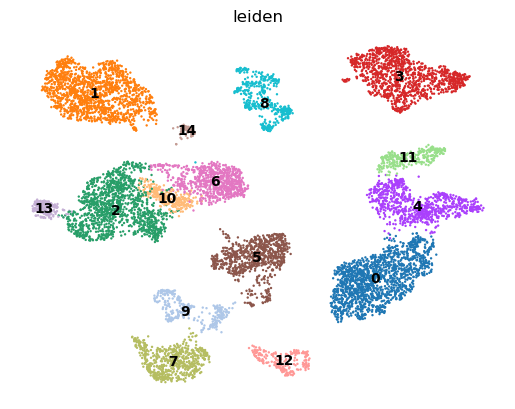

In [597]:
sc.pl.umap(dat1, color = ['leiden'], frameon = False, legend_loc = "on data")

In [598]:
dat1

AnnData object with n_obs × n_vars = 10097 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'Type'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Sample_colors', 'cell_type_colors', 'rank_genes_groups', 'Type_colors'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

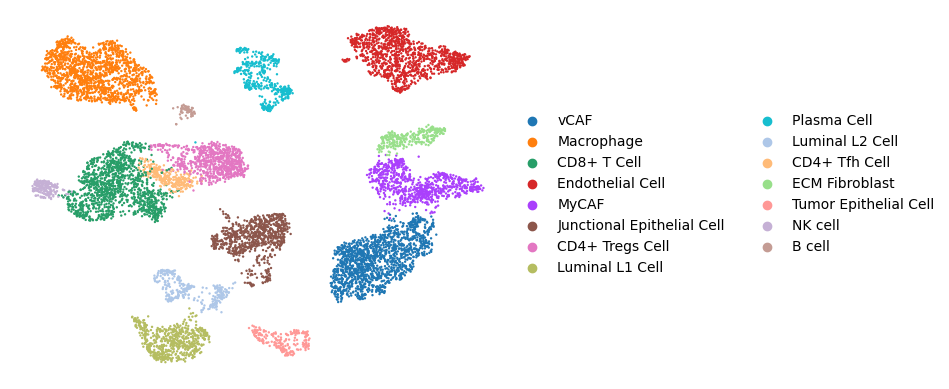

In [599]:
######################################################## labelling leiden clusters
Type = {
"0":'vCAF',
"1":'Macrophage',
"2":'CD8+ T Cell',
"3":'Endothelial Cell',
"4":'MyCAF',
"5":'Junctional Epithelial Cell',
"6":'CD4+ Tregs Cell',
"7":'Luminal L1 Cell',
"8":'Plasma Cell',
"9":'Luminal L2 Cell',
"10":'CD4+ Tfh Cell',
"11":'ECM Fibroblast',
"12":'Tumor Epithelial Cell',
"13":'NK cell',
"14":'B cell'    
}
dat1.obs['Type'] = dat1.obs.leiden.map(Type)

######################################################## plot
sc.pl.umap(dat1, color = ['Type'], frameon = False, title="",  save='UMAP_scrnaseq.png')

In [600]:
######################################################## wilcoxon DE
######################################################## Load APA gene list
polyadb_list = pd.read_csv('polyadb4_TR_gene_list.csv')['gene_symbol'].tolist()

######################################################## filter for adjusted p-value < 0.05 and log-fold-change > 0.5
de_genes_w = markers[(markers['pvals_adj'] < 0.05) & (markers['logfoldchanges'] > 0.5)].copy()
print(de_genes_w)
num_unique_genes = len(de_genes_w['names'].unique())
print(f"Number of significant DE genes (Wilcoxon): {num_unique_genes}")

######################################################## subset for HVGs
hvg_genes = dat1.var_names[dat1.var['highly_variable']]
de_genes_w_hvg = de_genes_w[de_genes_w['names'].isin(hvg_genes)].copy()
num_unique_hvg_de = len(de_genes_w_hvg['names'].unique())
print(f"Number of significant DE genes belonging to HVGs: {num_unique_hvg_de}")

######################################################## subset for APA genes
apa_de_genes_w = [g for g in polyadb_list if g in de_genes_w_hvg['names'].values]
num_unique_hvg_de_apa = len(set(apa_de_genes_w))
print(f"Number of APA DE genes belonging to HVGs: {num_unique_hvg_de_apa}")

######################################################## save
de_genes_w_hvg.to_csv("de_genes_w_hvg_filtered.csv", index=False)

matched_w = dat1[:, apa_de_genes_w]

       group     names     scores  logfoldchanges     pvals  pvals_adj
0          0    IGFBP7  54.453724        5.852284  0.000000   0.000000
1          0  NDUFA4L2  48.741276        7.992477  0.000000   0.000000
2          0   COL18A1  46.986382        5.179876  0.000000   0.000000
3          0      MYL9  46.932430        5.090674  0.000000   0.000000
4          0     CALD1  46.543716        4.653239  0.000000   0.000000
...      ...       ...        ...             ...       ...        ...
283804    14     RPL21   3.093271        0.579797  0.001980   0.046941
283805    14     RPS14   3.087173        0.548477  0.002021   0.047514
283806    14       ATM   3.079162        1.931944  0.002076   0.048368
283807    14     STRBP   3.071509        2.699206  0.002130   0.049233
283808    14      CHD2   3.070584        1.628091  0.002136   0.049330

[30024 rows x 6 columns]
Number of significant DE genes (Wilcoxon): 13214
Number of significant DE genes belonging to HVGs: 1662
Number of APA DE g

In [601]:
######################################################## scvi-DE
######################################################## Load APA gene list
polyadb_list = pd.read_csv('polyadb4_TR_gene_list.csv')['gene_symbol'].tolist()

######################################################## DE (markers_scvi)
markers_scvi.index.name = 'gene'

######################################################## filter for DE genes
de_genes = markers_scvi[(markers_scvi['is_de_fdr_0.05']) &(markers_scvi['lfc_mean'] > 0.5)].copy()

######################################################## subset for APA genes
apa_de_genes = [g for g in polyadb_list if g in de_genes.index and g in dat1.var_names]

######################################################## sort by lfc_mean
apa_de_genes = (de_genes.loc[apa_de_genes].sort_values('lfc_mean', ascending=False).index.tolist())
#pd.DataFrame(apa_de_genes, columns=['gene']).to_csv("apa_de_genes_sorted.csv", index=False)

######################################################## subet HVGs
hvg_genes = dat1.var_names[dat1.var['highly_variable']]
apa_de_genes_hvg = [g for g in apa_de_genes if g in hvg_genes]
#num_unique_apa_hvg = len(set(apa_de_genes_hvg))
#print(f"Number of unique APA DE genes within HVGs: {num_unique_apa_hvg}")

########################################################
matched_s = dat1[:, apa_de_genes_hvg]
print(f"Number of APA DE genes belonging to HVGs (SVCI): {len(matched_s.var_names.unique().tolist())}")
print("APA genes:", matched_s.var_names.unique().tolist())
#sc.pl.dotplot(matched,var_names=apa_de_genes, groupby="cell_type_2", swap_axes=True,save='_apa_genes_from_scvi_DE.png')

Number of APA DE genes belonging to HVGs (SVCI): 181
APA genes: ['SCGB1B2P', 'MUCL1', 'NKG7', 'FGFBP2', 'GZMB', 'TFF1', 'KRT7', 'DCN', 'HMGCS2', 'GZMH', 'DKK1', 'GNLY', 'APOD', 'LUM', 'SFRP2', 'WFDC2', 'BMPR1B', 'CXCL13', 'RAMP2', 'AGR2', 'CALML5', 'SPINK8', 'VWF', 'CTSW', 'CXCL14', 'PLVAP', 'KLRD1', 'GZMA', 'RGS5', 'PIP', 'PRF1', 'CD160', 'PDZK1', 'AGR3', 'SLPI', 'AQP1', 'DHRS2', 'DEGS2', 'KRT15', 'KRT19', 'FOLR1', 'DPT', 'CLDN5', 'MEG3', 'CLEC14A', 'KRT18', 'IGF1', 'AZGP1', 'CLDN3', 'COL1A1', 'ADGRL4', 'EMCN', 'ELF3', 'POSTN', 'SLC39A6', 'C1QC', 'CRABP2', 'S100P', 'COL3A1', 'STC2', 'HSPG2', 'NDUFA4L2', 'PLAC8', 'PARD6B', 'FCGR3A', 'FSIP1', 'TM7SF2', 'COL1A2', 'STARD10', 'C1QB', 'FAM3B', 'GDAP1', 'SRPX', 'LYZ', 'JCHAIN', 'CTHRC1', 'LTB', 'KLRB1', 'S100A8', 'TMEM150C', 'DNAJC12', 'FXYD3', 'NPY1R', 'CD34', 'CD69', 'C1QA', 'TRDC', 'BATF', 'SMIM22', 'IGFBP3', 'RARRES2', 'ISLR', 'GJA1', 'EGFL7', 'ACTA2', 'GNG11', 'COL18A1', 'MGST1', 'CD24', 'KRT8', 'ESAM', 'RAC3', 'CLDN4', 'CD93', 'CCL5', 

Wilcoxon: 1487
SCVI: 181
Number of shared genes: 181
Shared genes: ['ACADSB', 'AEBP1', 'AIF1', 'APOC1', 'APOE', 'AQP1', 'ARMT1', 'ATP6V0C', 'BATF', 'BIRC3', 'BMPR1B', 'C1QA', 'C1QB', 'C1QC', 'C1S', 'CALD1', 'CAV1', 'CCL4', 'CCND1', 'CD160', 'CD68', 'CLDN4', 'COL18A1', 'COL1A2', 'COL3A1', 'CPE', 'CTHRC1', 'CTSW', 'CXCL13', 'DBI', 'DHRS2', 'DKK1', 'EGFL7', 'ELF3', 'FAM3B', 'FCER1G', 'FOLR1', 'FTL', 'FXYD3', 'GDAP1', 'GJA1', 'GNG11', 'GNLY', 'GPRC5A', 'GZMA', 'HLA-DPB1', 'HLA-DRA', 'HMGA1', 'IGFBP6', 'ISLR', 'KLRD1', 'KRT18', 'KRT7', 'LRP1', 'LYZ', 'MEG3', 'MGST1', 'MMP2', 'MRPS30', 'MUCL1', 'MYL9', 'NME2', 'PARD6B', 'PCOLCE', 'PIP', 'PTGDS', 'RAC3', 'RAMP2', 'S100P', 'SMIM22', 'SPP1', 'TAGLN', 'TM7SF2', 'TPM1', 'TRDC', 'TRH', 'TSPAN13', 'WFDC2', 'ZG16B', 'ACTA2', 'ADGRL4', 'AGR2', 'AGR3', 'ANPEP', 'APOD', 'AZGP1', 'C1orf198', 'C1R', 'CALML5', 'CCDC80', 'CCL5', 'CD14', 'CD24', 'CD34', 'CD69', 'CD74', 'CD93', 'CLDN3', 'CLDN5', 'CLDN7', 'CLEC14A', 'CLIC3', 'COL1A1', 'COL6A3', 'COX6C', 'CRAB

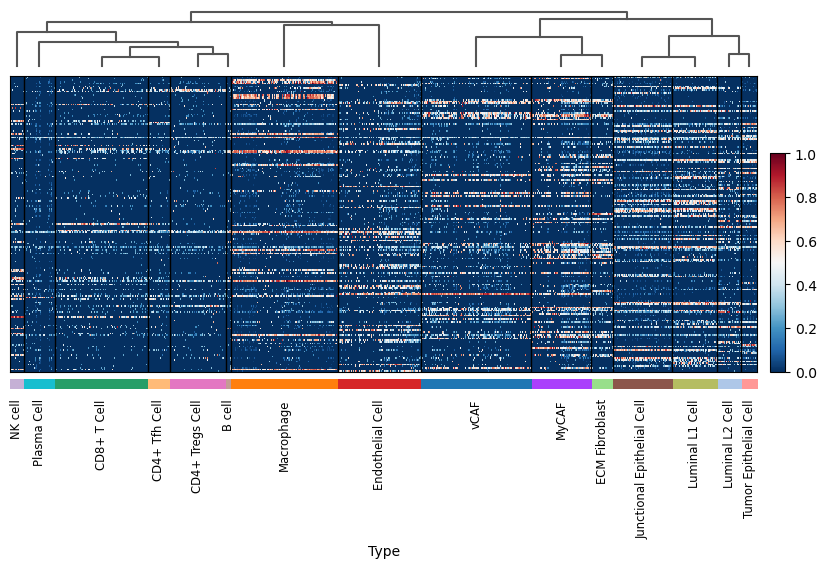

In [602]:
######################################################## genes that are present in both lists
genes_matched_w = matched_w.var_names.unique().tolist()
genes_matched_s = matched_s.var_names.unique().tolist()
print("Wilcoxon:", len(genes_matched_w))
print("SCVI:", len(genes_matched_s))

########################################################
shared_genes = [gene for gene in genes_matched_w if gene in genes_matched_s]

print(f"Number of shared genes: {len(shared_genes)}")
print("Shared genes:", shared_genes)

########################################################
shared_matched = dat1[:, shared_genes]
shared_matched.var_names_make_unique()

######################################################## plot heatmap
sc.pl.heatmap(
    shared_matched,
    var_names=shared_genes,
    groupby="Type",
    use_raw=False,
    cmap='RdBu_r',          
    standard_scale='var',   ### based on z-score
    swap_axes=True,
    dendrogram=True,        ### based on hierarchical clustering
    save="heatmap_stats_scrnaseq.png"
)

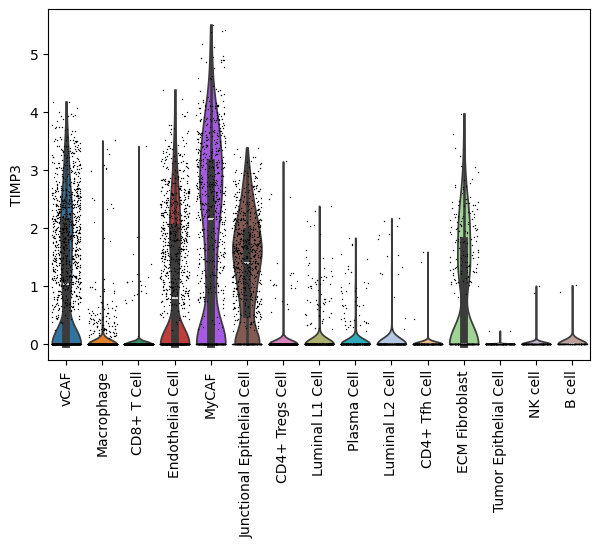

In [603]:
######################################################## plot violin plot
genename="TIMP3"
timp3_data = dat1[:, [genename]].copy()
########################################################
sc.pl.violin(timp3_data, keys=genename, groupby="Type", rotation=90, scale="width", inner="box", jitter=0.4, save=f"violin_{genename}.png")

In [611]:
######################################################## perform pairwise Mann–Whitney U tests
genename="TIMP3"
imp3_data = dat1[:, [genename]].copy()

expr = timp3_data[:, genename].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray().flatten()
groups = timp3_data.obs[groupby].values

plot_df = pd.DataFrame({"expression": expr,"group": groups})

######################################################## compute data
unique_groups = np.unique(groups)
pair_results = []

for g1, g2 in itertools.combinations(unique_groups, 2):
    x = plot_df.loc[plot_df['group'] == g1, 'expression']
    y = plot_df.loc[plot_df['group'] == g2, 'expression']
    stat, pval = mannwhitneyu(x, y, alternative='two-sided')
    pair_results.append({"group1": g1, "group2": g2, "pval": pval})

######################################################## adjust p-values
pvals = [r['pval'] for r in pair_results]
adj_pvals = multipletests(pvals, method='fdr_bh')[1]

for i, r in enumerate(pair_results):
    r['pval_adj'] = adj_pvals[i]

pair_results_df = pd.DataFrame(pair_results)

########################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

pair_results_df = pair_results_df.sort_values('pval_adj').reset_index(drop=True)

print(pair_results_df)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')
#pair_results_df.to_csv("TIMP3_pairwise_stats.csv", index=False)

                         group1                      group2           pval       pval_adj
0                   CD8+ T Cell  Junctional Epithelial Cell  4.273351e-288  4.487019e-286
1    Junctional Epithelial Cell                  Macrophage  2.864553e-277  1.503890e-275
2                   CD8+ T Cell                       MyCAF  5.479971e-242  1.917990e-240
3                    Macrophage                       MyCAF  3.538695e-228  9.289074e-227
4                   CD8+ T Cell                        vCAF  1.102754e-213  2.315782e-212
5                    Macrophage                        vCAF  5.996916e-201  1.049460e-199
6               CD4+ Tregs Cell  Junctional Epithelial Cell  6.868463e-191  1.030269e-189
7                   CD8+ T Cell            Endothelial Cell  1.031516e-180  1.353865e-179
8              Endothelial Cell                  Macrophage  8.448140e-161  9.856164e-160
9               CD4+ Tregs Cell                       MyCAF  3.133894e-159  3.290588e-158
10   Junct